# Dynamic Vision Sensors (DVS)
A not-so-recent technology developed to mimic the humain eye has been making strides in resource-intensive fields like robotics, manufacturing, among others. Just like the humain brain, these eye-mimicing sensors are power efficient and only use the data they need to detect what they need.

Lichtsteiner et al. worked on designing and engineering a sensor that could do just that, eventually being the core technology behind many commercially successful sensors like iniVation's [DAVIS346](https://shop.inivation.com/products/davis346?variant=31028381188150).

The design mainly is building a sensor with three main parts:
- Logarithmic Photoreceptor - detects light and uses logarithm to put it within an easier range to work with
- Differencing circuit - stores last event's voltage to compare with new one for further processing
- Comparator - determine if voltage change is big enough according to a predefined threshold
- Async communication logic - sends pixel address when change is detected

## Building a simplistic model of a DVS

#### Logarithmic photoreceptor

In [ ]:
def log_photoreceptor(I):
	return np.log(I + 1e-9) # to avoid 0s

#### Differencing circuit
Here, `gain` scales the result of the difference since the change in voltage can be very small (in mV). This very tiny difference in voltage is one reason why neuromorphic sensors are power-efficient and can work on edge devices.

In [31]:
def differencing_circuit(last_voltage, new_voltage, gain=10): # gain being approx. C1 / C2
	return gain * (last_voltage - new_voltage) # multiplying gain acts as the sort of thing an amplifier would do

### Comparator
This is when you decide which events to include through your choice of change in light (threshold). In other words, the comparator is a filtering process that tries to answer the question 'Is this enough voltage difference to care about?'

This helps:
- Avoid data noise
- Lessen power load

In [29]:
def comparator(voltage_diff, threshold):
    if voltage_diff > threshold:  # when scene brightens
        return "ON"
    elif voltage_diff < -threshold:  # when scene dims, i.e. when change in last two events is less than the negative of your threshold
        return "OFF"
    else:
        return None

# or if you prefer a more readable code
def readable_comparator(voltage_diff, threshold):
    if abs(voltage_diff) < threshold:
        return None
    return "ON" if voltage_diff > 0 else "OFF"

### Simulating how brightness would be processed

In [13]:
brightness = np.array([100, 102, 105, 120, 125, 126, 80, 70, 69, 68])
I_photo = brightness  # assume photocurrent is proportional to brightness

events = []
V_prev = None
threshold = 0.3  # try between 0.1–0.5 depending on how strict you want
gain = 5

for t in range(len(I_photo)):
    V = log_photoreceptor(I_photo[t])
    if V_prev is None:
        V_prev = V
        continue

    diff = differencing_circuit(V, V_prev, gain=gain)
    event = readable_comparator(diff, threshold)

    if event:
        events.append((t, event, diff))
        V_prev = V  # reset after event, just like the circuit!

for e in events:
    print(f"t={e[0]}, {e[1]} event, ΔV amplified = {e[2]:.3f}")


t=3, ON event, ΔV amplified = 0.912
t=6, OFF event, ΔV amplified = -2.027
t=7, OFF event, ΔV amplified = -0.668


### Previous attempts towards event-based sensors
A problem consistent with solutions prior to one proposed by the paper boils down to how there's a mismatch between pixels (i.e. baseline voltage is not uniform across pixels) caused by manufacturing variations. One can say that it's a design issue: choosing a transistor to act as a resistor (whose effective resistance isn’t fixed) makes it impossible to set a low threshold for the array.

A quick look at prior solutions
1. Mahowald & Mead's silicon model of the human eye - refer to earlier notes in the `01-bio-inspired-vision` folder. It is the foundational paper behind all silicon retina papers.
2. Zaghoul and Boahen
> This design comes closest to capturing key adaptive fea- tures of biological retinas. It is achieved by the use of small- transistor log-domain circuits that are tightly coupled spatially by diffuser networks. However, this circuit design style led to large mismatch: the pixel firing rates vary by a standard de- viation of 1–2 decades and more than half the pixels do not spike at all for stimuli with 50% contrast.
3.  CSEM Neuchatel's group
> The group at CSEM Neuchatel [5] presented a device that is closest to being dual in functionality to the one reported here in that its output encodes spatial rather than temporal contrast: After a global frame integration period, this device transmits events in the order of high-to-low spatial contrast. Thus, readout can be aborted early if limited processing time is avail- able without losing information about high-contrast features. Each contrast event is followed by another event that encodes gradient orientation. This device has low 2% contrast mismatch and a large 6 decade dynamic range. They are presently in commercial development for automotive applications [14]. The main limitation of this architecture is that it does not reduce temporal redundancy (compute temporal derivatives), and its temporal resolution is limited to the frame rate.
4. Etienne-Cumming
> Etienne-Cumming’s group reported a temporal change threshold detection imager [3], which modifies the traditional active pixel sensor (APS) CMOS pixel so that it can detect a quantized absolute change in illumination

### Pixel Design Proposed
<img src="pixel-core.png" alt="Abstract Pixel Core Schematic" width="50%">

Lichtsteiner et al. proposes a chip design that solves the mismatch stated earlier through the addition of a logarithmic photoreceptor, differencing circuit (that acts as a high precision amplifier), and a transistor-based comparator.

What makes it different than other designs?
This is design is different than previous designs in that it accounts for the pixel mismatch that result in that each pixel's voltage is not basedlined, and therefore a pixel can carry unwanted residual. To solve this, a differencing circuit is introduced to reset voltage after an event is produced (ON/OFF). A comparator is then used to categorize whether that event is ON (pixel is brighter than previous pixel) or OFF (pixel is dimmer than previous pixel). This change in brightness (or current), in mathematical terms, can be represented as:
$$
T_{\mathrm{CON}} = \frac{1}{I(t)} \frac{dI(t)}{dt} = \frac{d\left( \ln(I(t)) \right)}{dt}
$$
where TCON is temporal contrast and I(t) is current at time t.

Side note: One advantage this design has is its consideration for high-speed vision. Unlike a traditional photoreceptor, the design adds puts the photodiode of the photoreceptor in a feedback loop with an amplifier to introduce gain, thereby accounting for the tiny amount of current existing in low-light scenes. This is also reinforced by the fact that the photoreceptor circuit has adaptive biasing, a way to tweak current and voltage for optimal power consumption.

Practically, if light goes through the pixel core design, it would be through these steps:
1. Light (photocurrent) is receieved by the photodiode and converted into voltage through the logarithmic photoreceptor circuit
2. > The photoreceptor output is buffered with a source follower to isolate the sensitive photoreceptor from the rapid transients in the differencing circuit. 
3. The voltage is then received by the differencing circuit to calculate the scaled `V_diff` and the circuit is shorted to reset voltage to baseline level.
4. Comparators are then used to compare resulting output of the inverting amplifier (that of the differencing circuit) to global threshold set by the designer to detect changing brightness. An ON/OFF event is generated.
5. The the category of the event then determines the output of the AE handshake. If event is ON, then the request Column Request ON signal is generated and an acknowledge signal of Column acknowlege (more on this later)


How does light go through the design?


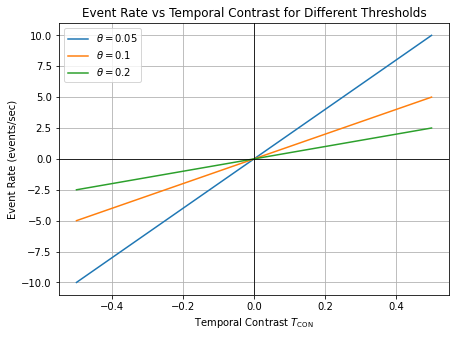

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Temporal contrast range (TCON)
TCON_values = np.linspace(-0.5, 0.5, 200)  # negative = dimmer, positive = brighter

# Different thresholds
theta_values = [0.05, 0.1, 0.2]  # low, medium, high threshold

plt.figure(figsize=(7,5))

for theta in theta_values:
    event_rate = TCON_values / theta
    plt.plot(TCON_values, event_rate, label=fr"$\theta = {theta}$")

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(r"Temporal Contrast $T_{\mathrm{CON}}$")
plt.ylabel("Event Rate (events/sec)")
plt.title("Event Rate vs Temporal Contrast for Different Thresholds")
plt.legend()
plt.grid(True)
plt.show()

### Other parts of the sensor
- Address-Event Interface: Contained in the AER communication periphery (which helps connect event outputs to sensor pins), where 7 bit x-addresses and 7 bit y-addresses, and ON/OFF polarity bit - making the chip output 15-bit digital address.
- Programmble Bias Generator: Helps set the biases through a digital interface according to functionality and feedback control
- Connections to external devices using USB

### Characteristics of the sensor
1. Uniformity of Response: It tries to eliminate mismatch of pixels by setting a reset baseline through the implementation of a switched-capacitor differencing circuit (calculates diff in voltage, but immediately resets voltage to baseline once event is recieved) instead of the old transistor resistor. 
2. Dynamic Range: up to 120 dB in illuminace range, mainly as a byproduct of the allowance of setting the contrast threshold.
3. Pixel Bandwidth: pixels to react fast enough to detect changes in a scene.
4. Latency: Low latency (15 µ) as a result of low threshold acceptance, voltage reset, individual event trigger.

## Conclusion
This paper is a major one in that it helped solve the mismatch problem that other papers had yet to solve. It solved it mainly by redesigning the sensor so that each pixel is relatively compared to its predecessor in a timely manner. The redesign adds programmable bias generator and introduces AER circuits, both helping in introducing more control and making it dynamic so that sensor proactively reacts to light under a wide range of conditions. Asychoronous Event Representation, or AER, helps make the design on-premise and scalable. In essence, through the effective generation of events, the sensor ensures low latency, high bandwidth, response uniformity, and low threshold.